# **PROYECTO: ANÁLISIS DE EXPLORATORIO DE DATOS**

Cada **proceso del análisis** deberá ser mostrado en este notebook:

*   **Recopilación de datos.**
*   **Limpieza de datos.**
*   **Exploración de datos.**
*   **Visualización de datos.**

# **1. Configuracion inicial**

In [7]:
# Datos
import pandas as pd
import numpy as np

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
sns.set_style('darkgrid')
%matplotlib inline

# Warning
import warnings
warnings.filterwarnings('ignore')

# **2. Introduccion del proyecto**

En este proyecto nos basaremos en el conjunto de datos de Kaggle:

[IMDb Top Movies 1980-2026](https://www.kaggle.com/datasets/elvisbui/imdb-top-movies-1980-2026)

IMDb (por sus siglas en inglés, Internet Movie Database) es la base de datos de películas y televisión más grande, popular y completa del mundo en internet. Propiedad de Amazon desde 1998, sirve como una gigantesca enciclopedia del entretenimiento.



## **2.1 Acerca del dataset**

Todas las películas de largometraje incluidas en IMDb estrenadas a partir de 1980 y que cuentan con al menos 5.000 votos de los usuarios. Datos extraídos de los conjuntos de datos oficiales no comerciales de IMDb (title.basics y title.ratings) a fecha de 28 de abril de 2026.

Una fila por película. Incluye el título, el título original, el año, la duración, los géneros separados por comas, la puntuación media en IMDb, el número de votos y la URL canónica de IMDb. Ordenado por número de votos en orden descendente, de modo que las películas más vistas y más comentadas aparecen en los primeros puestos.

Se han filtrado únicamente los largometrajes no destinados a adultos; se excluyen las series de televisión, los cortometrajes y el contenido para adultos.

## **2.2 Descripcion columnas**

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| **imdb_id** | `object` (Texto) | Identificador `tconst` de IMDb (por ejemplo, tt0111161 para *The Shawshank Redemption*). |
| **title** | `object` (Texto) | Título principal (en inglés cuando corresponda). |
| **original_title** | `object` (Texto) | Título en el idioma original. |
| **year** | `int64` (Entero) | Año de estreno. |
| **runtime_minutes** | `float64` (Decimal) | Duración de la película en minutos. |
| **genres** | `object` (Texto) | Etiquetas de género de IMDb separadas por comas. |
| **average_rating** | `float64` (Decimal) | Calificación promedio ponderada de IMDb (0-10). |
| **num_votes** | `int64` (Entero) | Número total de votos de usuarios contabilizados para la calificación. |
| **imdb_url** | `object` (Texto) | Enlace directo a la película (https://www.imdb.com/title/). |

# **3. Recopilacion y carga de datos**

In [8]:
path = "../data/raw/imdb_top_movies_1980_2026.csv"

print("Primeras filas del dataset: \n")
df = pd.read_csv(path)
df.head()

Primeras filas del dataset: 



,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692


In [9]:
print("Informacion del dataset: \n")
df.info()

Informacion del dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 16252 entries, 0 to 16251
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16252 non-null  str    
 1   title            16252 non-null  str    
 2   original_title   16252 non-null  str    
 3   year             16252 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16246 non-null  str    
 6   average_rating   16252 non-null  float64
 7   num_votes        16252 non-null  int64  
 8   imdb_url         16252 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 1.1 MB


* De acuerdo a la informacion del dataset tendremos que ver los valores vacios o nulos, y elegir el tratamiento adecuado

# **4. Limpieza de Datos**



In [10]:
print("Informacion de nulos: ")
df.isnull().sum()

Informacion de nulos: 


imdb_id            0
title              0
original_title     0
year               0
runtime_minutes    1
genres             6
average_rating     0
num_votes          0
imdb_url           0
dtype: int64

## **4.1 Tratamiento nulos**

### **4.1.1 Runtime minutes**

In [11]:
print("Informacion de valor nulo en runtime_minutes: ")
df[df['runtime_minutes'].isnull()]

Informacion de valor nulo en runtime_minutes: 


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
14587,tt29332321,Wendigo,Wendigo,2011,NaN,Horror,7.7,6100,https://www.imdb.com/title/tt29332321


#### **El misterio de "Wendigo (2011)" en IMDb:**

* ¿Solo un tráiler? Aunque en IMDb aparece con más de 6,000 votos y una calificación muy alta (7.7), personas de la comunidad de preservación de cine de terror contactaron directamente al guionista (Sean McDonough). Él confirmó que el proyecto solo llegó a filmar y lanzar un tráiler oficial de 2 minutos (financiado originalmente en Kickstarter bajo el sello Brilliant Morgan Entertainment).

* El "Glitch" de los votos: Es muy probable que el ID de IMDb haya sufrido una fusión de datos o un error de indexación con alguna otra producción del mismo nombre o que los votos se hayan inflado por confusión con el mito del Wendigo, ya que un largometraje comercial completo bajo esa dirección exacta nunca tuvo una distribución masiva.

*Por tal motivo lo mejor seria eliminarlo para evitar el outlier evidente de 2 minutos**

In [12]:
df = df.dropna(subset=['runtime_minutes'])

### **4.2 Genres**

In [13]:
print("Informacion de generos nulos: ")
df[df['genres'].isnull()]

Informacion de generos nulos: 


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
3921,tt7668842,Enes Batur: Imagination or Reality?,Enes Batur Hayal mi Gerçek Mi?,2018,110.0,NaN,2.0,56758,https://www.imdb.com/title/tt7668842
11569,tt28754073,Heer Express,Heer Express,2025,142.0,NaN,5.3,9173,https://www.imdb.com/title/tt28754073
15116,tt32135732,The Devil,The Devil,2025,167.0,NaN,9.0,5715,https://www.imdb.com/title/tt32135732
15311,tt33291804,Meesha,Meesha,2025,131.0,NaN,6.5,5582,https://www.imdb.com/title/tt33291804
16106,tt29856129,Mayanagari,Mayanagari,2023,137.0,NaN,3.8,5086,https://www.imdb.com/title/tt29856129
16136,tt36329718,916 Kunjuttan,916 Kunjuttan,2025,116.0,NaN,5.1,5067,https://www.imdb.com/title/tt36329718


**Al ser pocos valores nulos y ya que no queremos eliminar estos datos ya que el genero es una columna con un valor categorico, con una breve busqueda en internet podemos obtener el genero**

In [14]:
# Diccionario con los géneros reales mapeados por ID
generos_reales = {
    'tt7668842': 'Comedy',
    'tt28754073': 'Drama, Musical',
    'tt32135732': 'Action, Drama, Thriller',
    'tt33291804': 'Drama, Suspense',
    'tt29856129': 'Horror, Thriller',
    'tt36329718': 'Drama, Family'
}

# Rellenar los NaN usando el mapeo solo donde falte el dato
df['genres'] = df['genres'].fillna(df['imdb_id'].map(generos_reales))

## **4.2 Duplicados**

In [15]:
print(f"Datos duplicados: {df.duplicated().sum()}")


Datos duplicados: 0


# **5. Exploración de Datos (EDA)**

In [16]:
print("Estadisticas descriptivas: \n")
df.describe()

Estadisticas descriptivas: 



,year,runtime_minutes,average_rating,num_votes
count,16251.000000,16251.000000,16251.000000,1.625100e+04
mean,2008.789982,109.147376,6.395114,6.633542e+04
std,11.581349,22.110801,1.050890,1.557406e+05
min,1980.000000,43.000000,1.000000,5.000000e+03
25%,2001.000000,94.000000,5.800000,8.400500e+03
50%,2011.000000,104.000000,6.500000,1.726800e+04
75%,2018.000000,119.000000,7.100000,5.387050e+04
max,2026.000000,566.000000,9.300000,3.182733e+06


**Podemos observar lo siguiente:**

1. year: Mayor rango de 2011 a 2026 (Normal a que el cine moderno es mas comun tener registros y documentacion que decadas de los 80-90)

2. runtime_minutes: Valor maximo excesivo 566 minutos (Posible Outlier, ya que la mayoria de peliculas estan en un rango normal)

3. average_rating: Distribucion normal con limites de 1.0 es un fracaso absoluto catastrófico, y el 9.3 un exito rotundo.

4. num_votes: El numero de votos es muy dependiente sin embargo el 50% de las peliculas tienen 17,268 votos o menos. y el máximo es de 3,182,733 votos, esto si bien puede ser normal para un exito rotundo habria que considerar las evaluaciones.

## **5.1 Runtime Minutes**

In [17]:
df[df['runtime_minutes'] == df['runtime_minutes'].max()]

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
10171,tt0090015,Shoah,Shoah,1985,566.0,"Documentary,History,War",8.7,11578,https://www.imdb.com/title/tt0090015


**Shoah es una obra maestra monumental del director Claude Lanzmann sobre el Holocausto. Es un documental histórico extremadamente riguroso que, en efecto, dura 9 horas y 26 minutos**

Recomendaciones:

1. Aunque el dato es correcto, Shoah sigue siendo un outlier estadístico (un valor atípico). Si se quiere entrenar un modelo de Machine Learning (por ejemplo, para predecir la calificación de una película basada en duracion), mantener una película de 9 horas va a distorsionar la pendiente de las regresiones o desordenar los árboles de decisión. Por obvias razones seria mejor eliminarla

2. Crear un subconjunto acotado para trabajar el modelo, limitando la duración al grueso de la industria (por ejemplo, menos de 240 minutos / 4 horas)

## **5.2 Num Votes**



In [18]:
df[df['num_votes'] == df['num_votes'].max()]

,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161


¡El rey indiscutible de IMDb! The Shawshank Redemption (1994) (conocida en Latinoamérica como **Sueños de Fuga**).

No hay errores de desbordamiento de enteros (integer overflow) ni registros corruptos: el máximo de votos le pertenece, tal como dicta la realidad, a la película mejor calificada y más votada en la historia de la plataforma.

[Sueños de Fuga](https://www.imdb.com/title/tt0111161)

[Las 250 mejores películas de IMDb](https://www.imdb.com/es/chart/top/?ref_=hm_nv_menu)


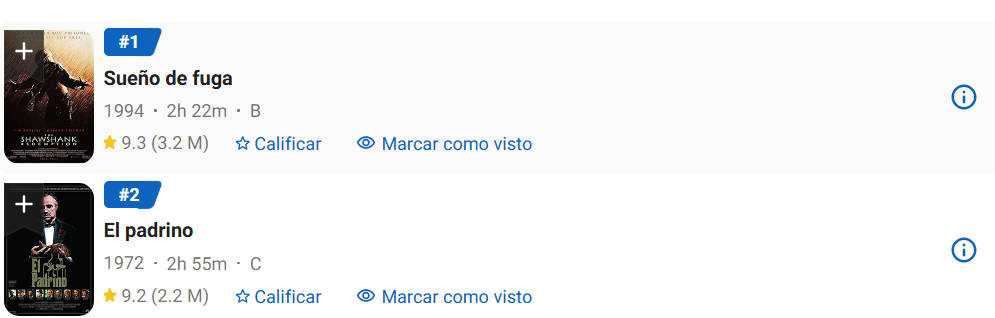

**Recomendaciones:**

1. Para solucionar este sesgo estadístico, hay que una transformación logarítmica. Esto comprime la escala de los valores gigantescos sin perder la diferencia de orden de magnitud:



In [19]:
df['log_num_votes'] = np.log1p(df['num_votes'])
print("Columna logaritmica creada")

Columna logaritmica creada


In [20]:
df.describe()

,year,runtime_minutes,average_rating,num_votes,log_num_votes
count,16251.000000,16251.000000,16251.000000,1.625100e+04,16251.000000
mean,2008.789982,109.147376,6.395114,6.633542e+04,10.082882
std,11.581349,22.110801,1.050890,1.557406e+05,1.266099
min,1980.000000,43.000000,1.000000,5.000000e+03,8.517393
25%,2001.000000,94.000000,5.800000,8.400500e+03,9.036165
50%,2011.000000,104.000000,6.500000,1.726800e+04,9.756668
75%,2018.000000,119.000000,7.100000,5.387050e+04,10.894357
max,2026.000000,566.000000,9.300000,3.182733e+06,14.973251


# **6. Visualización de Datos Univarible**

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 16251 entries, 0 to 16251
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16251 non-null  str    
 1   title            16251 non-null  str    
 2   original_title   16251 non-null  str    
 3   year             16251 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16251 non-null  str    
 6   average_rating   16251 non-null  float64
 7   num_votes        16251 non-null  int64  
 8   imdb_url         16251 non-null  str    
 9   log_num_votes    16251 non-null  float64
dtypes: float64(3), int64(2), str(5)
memory usage: 1.4 MB


## **6.1 Categorias/Objects**

Si bien tenemos 5 columnas de objeto o string, para la visualizacion como categoria solo tenemos el genero, que es la columna a graficar.

Al existir infinidad de genero consideraremos el top 15 de generos mas populares.

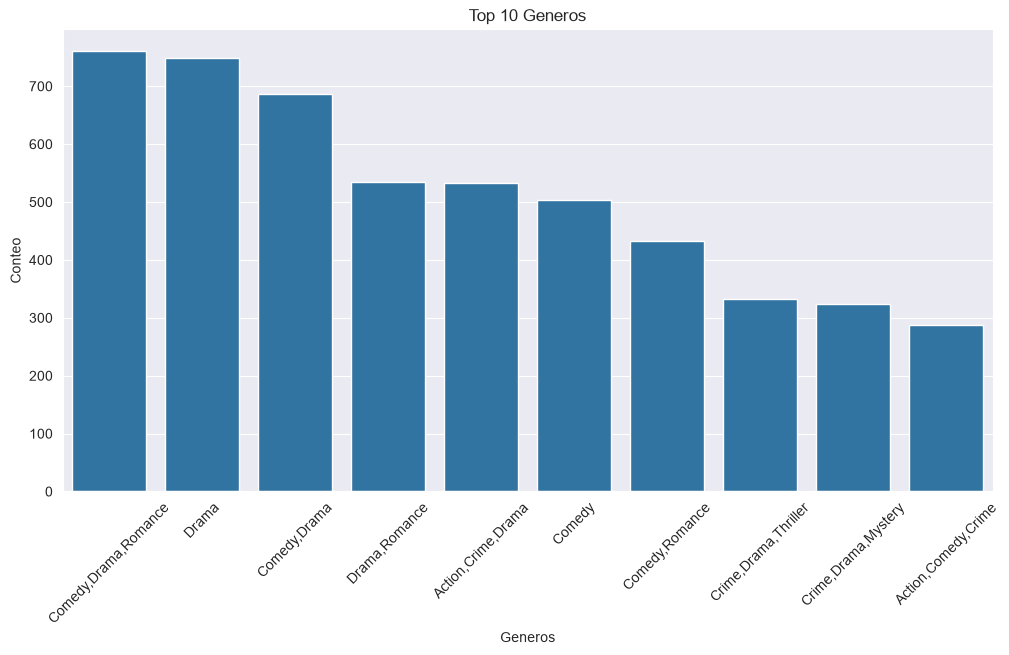

In [22]:
# Conteo de generos top 10
plt.figure(figsize=(12, 6))
top_10_genres = df['genres'].value_counts().head(10)
sns.barplot(x=top_10_genres.index, y=top_10_genres.values)
plt.title('Top 10 Generos')
plt.xlabel('Generos')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.show()


* El Drama y la Comedia dominan el mundo

Si sumamos rápidamente las combinaciones donde aparecen estas dos categorías,acaparan la gran mayoría de las más de 16,000 películas.

El subgénero de "Comedy, Drama, Romance" es el rey absoluto con 760 películas, seguido muy de cerca por el "Drama" puro (749).

Esto es un comportamiento demográfico muy normal en el cine: se producen muchísimas más películas de drama, comedia y romance que películas de ciencia ficción o fantasía con presupuestos masivos.

### **6.1.1 Generos individuales**

In [23]:
# 1. Separar los géneros por la coma
df['genres_split'] = df['genres'].str.split(',')

# Usamos .explode() para separar las listas en filas,
# y luego .str.strip() para borrar los espacios en blanco, NO .split()
genres_clean = df['genres_split'].explode().str.strip()

# 3. Reemplazar 'Suspense' por 'Thriller'
genres_clean = genres_clean.replace('Suspense', 'Thriller')

# 4. Contar los valores
genres_count = genres_clean.value_counts()

print(genres_count)

genres_split
Drama          9223
Comedy         5875
Action         3942
Crime          3256
Thriller       2779
Romance        2652
Adventure      2337
Horror         2193
Mystery        1754
Biography      1130
Fantasy        1091
Sci-Fi          963
Animation       751
Family          660
History         628
Documentary     558
Music           515
Sport           354
War             289
Musical         177
Western          73
News              7
Name: count, dtype: int64


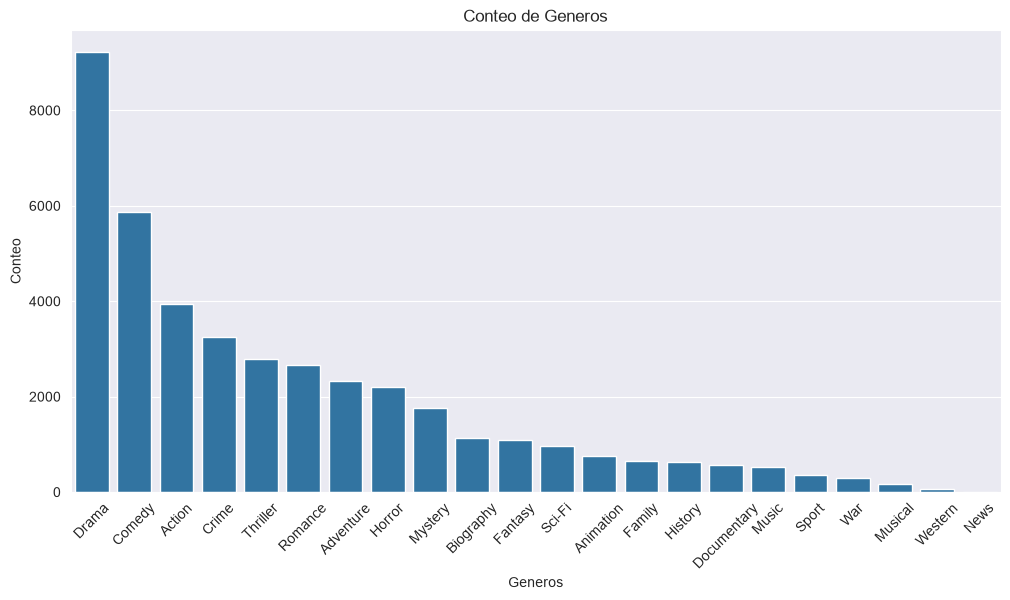

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x=genres_count.index, y=genres_count.values)
plt.title('Conteo de Generos')
plt.xlabel('Generos')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.show()

1. La Regla del "Top 5" (Concentración del Mercado)

El dataset está masivamente dominado por cinco géneros: Drama, Comedia, Acción, Crimen y Thriller.

* Si sumamos las frecuencias de estos 5 géneros, acumulan 25,075 menciones.

* Esto nos dice que la gran mayoría de las películas en tu dataset combinan estos elementos entre sí (por ejemplo, Acción-Crimen o Comedia-Drama). El drama es el rey indiscutible: está presente en más de la mitad de todo el volumen de datos.

2. El Bloque Comercial Intermedio (Fantasía y Ciencia Ficción)

Es muy interesante ver cómo géneros de alto presupuesto como Sci-Fi (963) y Fantasy (1,091) están en la parte media-baja de la tabla.

* Interpretación: Aunque son los géneros que suelen romper las taquillas a nivel mundial (como las películas de superhéroes o franquicias espaciales), en volumen real de producción anual se hacen muchísimas menos películas de este tipo debido a los altísimos costos de efectos especiales, en comparación con un Drama o una Comedia que son más baratos de filmar.

3. Los Géneros de Nicho (La "Cola Larga")

A partir de Animation (751) hacia abajo, entramos en géneros muy específicos o de nicho.

* Sorprende ver al Western (73) tan abajo; esto confirma que el género clásico de vaqueros, aunque tuvo una época dorada en el siglo XX, hoy en día es casi una rareza estadística en la producción moderna.

* El género News (7) es el más pequeño. Al tener un número tan sumamente bajo (0.04% del dataset), representa una anomalía de clasificación.

**Si se va a entrenar un modelo predictivo, se recomienda eliminar por completo esas 7 filas o remapearlas a Documentary, ya que una muestra tan pequeña solo meterá ruido al algoritmo.**

## **6.2 Distribuciones**

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 16251 entries, 0 to 16251
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16251 non-null  str    
 1   title            16251 non-null  str    
 2   original_title   16251 non-null  str    
 3   year             16251 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16251 non-null  str    
 6   average_rating   16251 non-null  float64
 7   num_votes        16251 non-null  int64  
 8   imdb_url         16251 non-null  str    
 9   log_num_votes    16251 non-null  float64
 10  genres_split     16251 non-null  object 
dtypes: float64(3), int64(2), object(1), str(5)
memory usage: 1.5+ MB


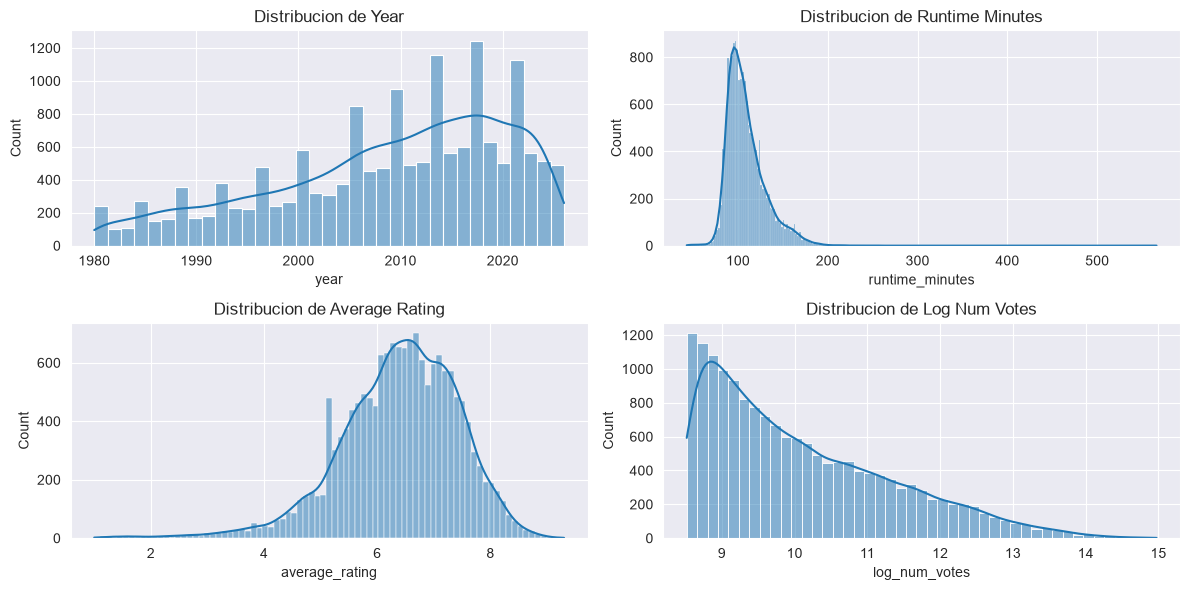

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Distribucion de year
sns.histplot(df['year'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribucion de Year')

# Distribucion de runtime_minutes
sns.histplot(df['runtime_minutes'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribucion de Runtime Minutes')

# Distribucion de average_rating
sns.histplot(df['average_rating'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribucion de Average Rating')

# Distribucion de log_num_votes
sns.histplot(df['log_num_votes'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribucion de Log Num Votes')

plt.tight_layout()
plt.show()


1. Distribución de Year (Asimetría Negativa / Left-Skewed)

* Lo que se observa: La gráfica muestra un crecimiento constante desde 1980, con picos masivos de producción a partir de 2010 y una ligera caída al final (normal en años recientes por el desfase de indexación de IMDb).

* Insight de negocio: Confirma visualmente que tu dataset está sesgado hacia el cine contemporáneo. Hay un patrón cíclico muy interesante (los picos y valles repetitivos año con año), que suele deberse a la acumulación de registros en años específicos de estreno de grandes franquicias o cambios en cómo IMDb recopila datos.

2. Distribución de Runtime Minutes (Cola Larga Extrema hacia la Derecha)

* Lo que se observa: Es una distribución sumamente esbelta y concentrada (leptocúrtica). La inmensa mayoría de las películas forman una "aguja" perfecta alrededor de los 90-140 minutos.

* El detalle del Outlier: La línea azul se extiende plana y vacía hacia la derecha hasta llegar casi al 600. Esa eterna línea plana representa visualmente a Shoah (1985) como habiamos visto anteriormente y a cualquier otra película de más de 4 horas.

* Conclusión de limpieza para modelo: Para un modelo predictivo se debe recortar el eje $X$ (por ejemplo, plt.xlim(40, 200)) para remover esa cola vacía que solo añade ruido.

3. Distribución de Average Rating (Aproximación Normal)

* Lo que se observa: De las cuatro variables, esta es la única que se comporta casi como una campana de Gauss perfecta (Distribución Normal), centrada ligeramente a la derecha (alrededor de 6.5).

* El "Diente" Extraño: Hay una anomalía visual muy obvia: una barra inusualmente alta justo en la calificación de 5.0.

* Insight: En plataformas de votación, el 5.0 suele ser el valor por defecto de "indiferencia" o el resultado de un sesgo de usuarios que califican con 1 o 10 y promedian exactamente a la mitad. También hay una caída abrupta después del 8.0, lo que demuestra lo difícil que es para una película mantener el estatus de "obra maestra" de forma masiva.

4. Distribución de Log Num Votes (Distribución Bimodal / Suavizada)

* Lo que se observa: Si se hubiera graficado los votos originales, se habria visto una sola barra gigante a la izquierda y nada más. Al aplicar el logaritmo, se pudo observar la verdadera estructura.

* El patrón oculto: Se observa una ligera tendencia bimodal o de doble caída. Al tener una acumulación masiva de películas al principio del eje X (películas con pocos votos, el umbral mínimo que ronda los 5,000 votos) y luego una pendiente suave hacia la derecha donde habitan los éxitos de taquilla (como The Shawshank Redemption en el extremo derecho cercano a 15 el top 1).


# **7. Visualizacion de Datos Multivaribles**

## **7.1 Matriz de correlacion**


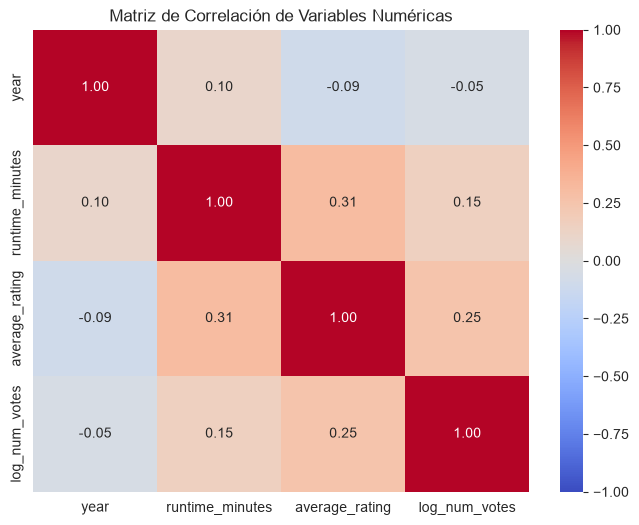

In [27]:
columnas_num = ['year', 'runtime_minutes', 'average_rating', 'log_num_votes']
matriz_corr = df[columnas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

## **7.2 ¿El paso del tiempo afecta la calidad o el engagement?**

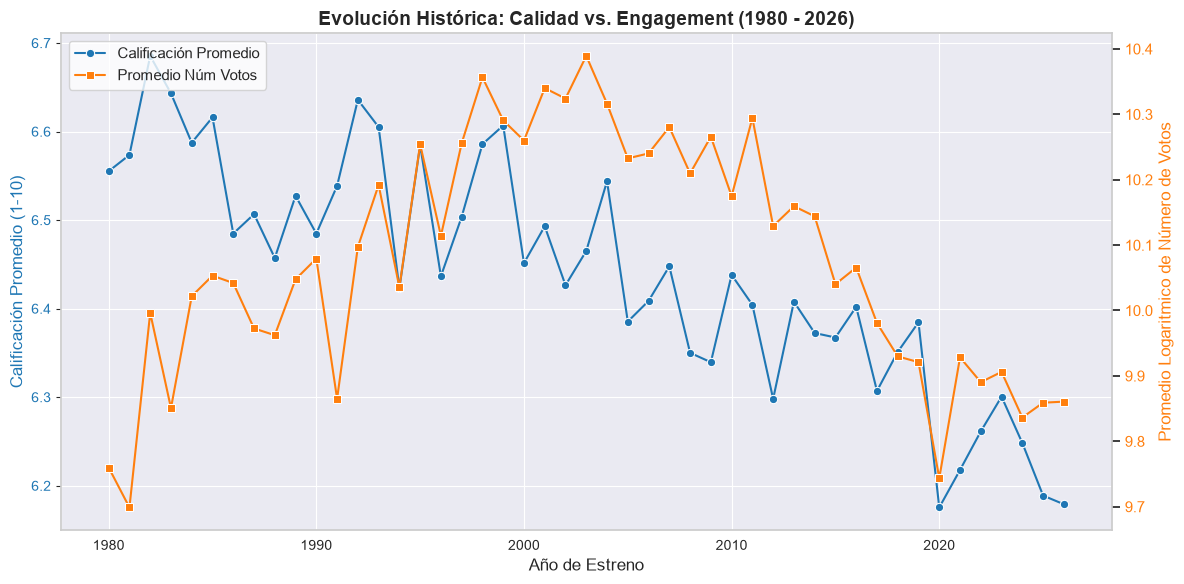

In [28]:
df_by_year = df.groupby('year').agg({'average_rating': 'mean',
                                     'log_num_votes': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(x='year', y='average_rating', data=df_by_year,
             color='tab:blue', marker='o', ax=ax1, label='Calificación Promedio')
ax1.set_xlabel('Año de Estreno', fontsize=12)
ax1.set_ylabel('Calificación Promedio (1-10)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.get_legend().remove() # Removemos leyenda individual para hacer una limpia al final


ax2 = ax1.twinx()


sns.lineplot(x='year', y='log_num_votes', data=df_by_year,
             color='tab:orange', marker='s', ax=ax2, label='Promedio Núm Votos')
ax2.set_ylabel('Promedio Logaritmico de Número de Votos', color='tab:orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.grid(False)
ax2.get_legend().remove()


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Evolución Histórica: Calidad vs. Engagement (1980 - 2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**El análisis temporal demuestra que el engagement de la comunidad (votos) y la calificación promedio no son estáticos; estuvieron fuertemente acoplados entre 1990 y 2010. No obstante, el cine moderno (2015-2026) se caracteriza por un aumento en el volumen de datos pero con una tendencia clara hacia calificaciones promedio más bajas y críticas por parte de los usuarios.**

## **7.3. ¿La duración de una película influye en su calificación?**

Al exitir el outlier de 9 horas (Shoah), limitaremos el eje X a 200 minutos para ver el comportamiento real del grueso de la industria.

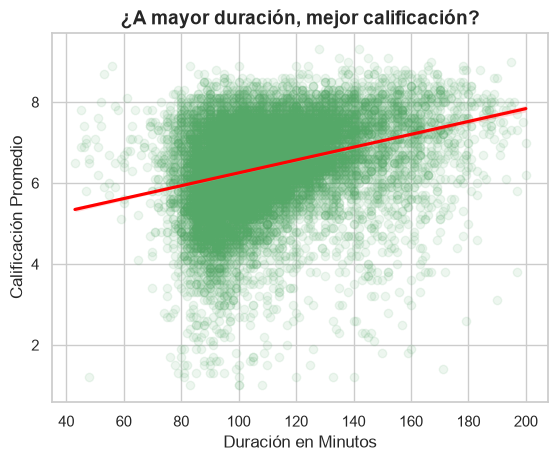

In [29]:
df_filtrado = df[df['runtime_minutes'] <= 200]

sns.regplot(data=df_filtrado, x='runtime_minutes', y='average_rating',
            scatter_kws={'alpha':0.1, 'color': 'g'}, line_kws={'color': 'red'})

plt.title('¿A mayor duración, mejor calificación?', fontsize=14, fontweight='bold')
plt.xlabel('Duración en Minutos')
plt.ylabel('Calificación Promedio')
plt.show()

**El análisis bivariado confirma una relación positiva entre la duración y la calificación percibida. Se evidencia un fenómeno de control de calidad: mientras que las películas de duración estándar (80-100 min) abarcan todo el espectro de calificaciones (desde obras pésimas hasta excelentes), las producciones que superan los 140 minutos mantienen un estándar de calidad mínimo, eliminando casi por completo las calificaciones reprobatorias inferiores a 4.0.**

## **7.3 ¿Qué géneros son los favoritos del público y cuáles mueven más masas?**

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 16251 entries, 0 to 16251
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16251 non-null  str    
 1   title            16251 non-null  str    
 2   original_title   16251 non-null  str    
 3   year             16251 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16251 non-null  str    
 6   average_rating   16251 non-null  float64
 7   num_votes        16251 non-null  int64  
 8   imdb_url         16251 non-null  str    
 9   log_num_votes    16251 non-null  float64
 10  genres_split     16251 non-null  object 
dtypes: float64(3), int64(2), object(1), str(5)
memory usage: 1.5+ MB


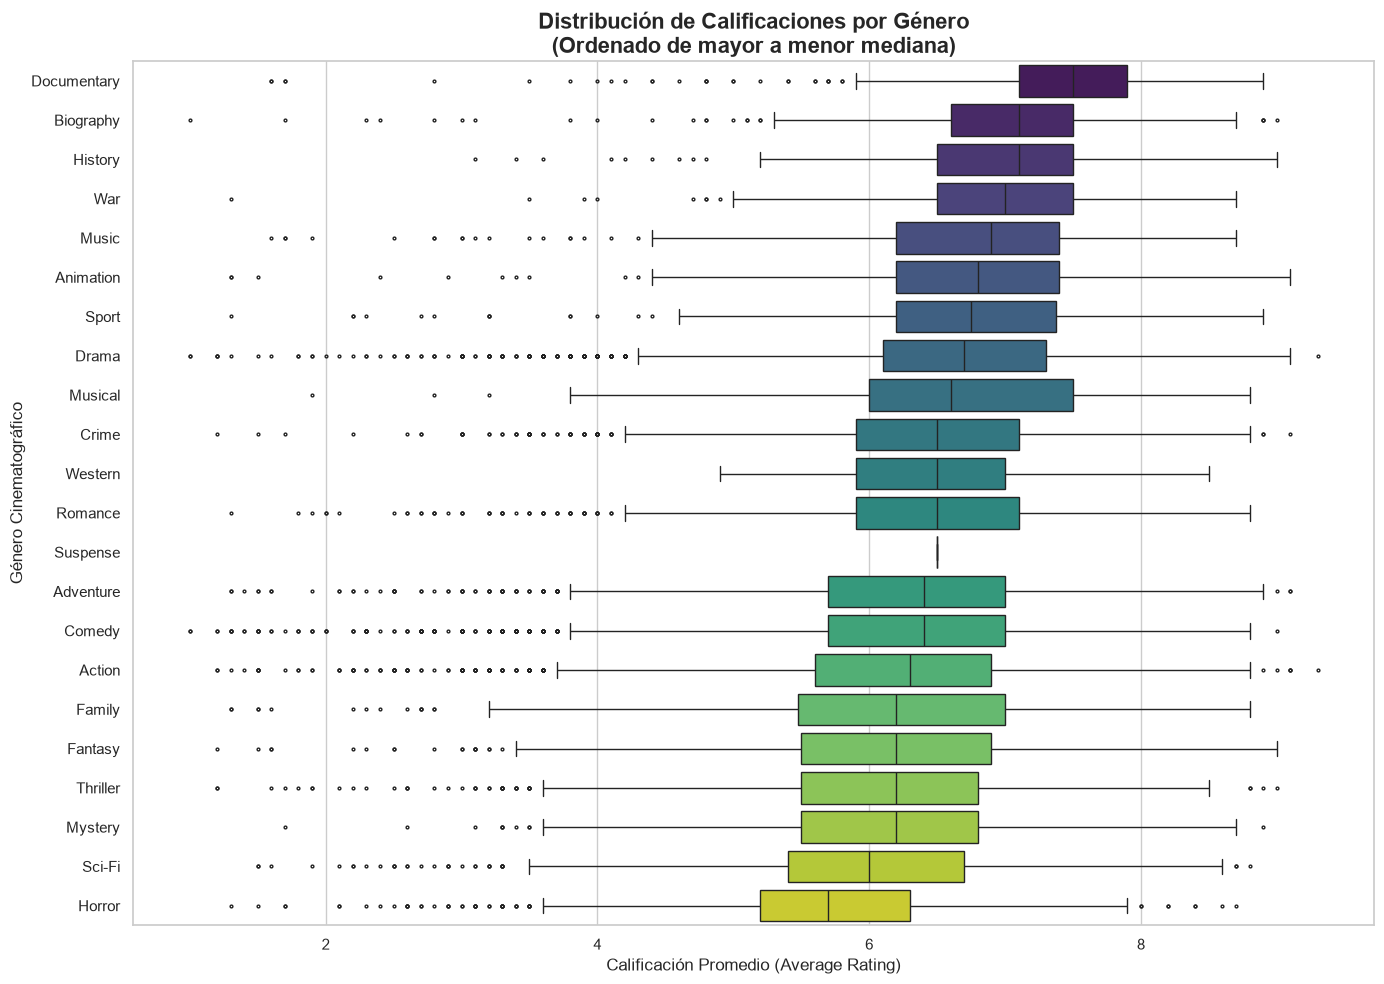

In [31]:
df_exploded = df.copy()
df_exploded = df.explode('genres_split')

# Creamos la columna limpia aplicando el .str.strip()
df_exploded['genres_clean'] = df_exploded['genres_split'].str.strip()

# 3. Eliminamos 'News' ya que solo tiene 7 películas y no aporta al análisis masivo
df_exploded = df_exploded[df_exploded['genres_clean'] != 'News']

# 4. Calculamos las medianas para ordenar el gráfico de mejor a peor calificación
orden_generos = df_exploded.groupby('genres_clean')['average_rating'].median().sort_values(ascending=False).index


plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df_exploded,
    x='average_rating',
    y='genres_clean',
    order=orden_generos,
    palette='viridis',
    fliersize=2
)

# 7. Personalizar títulos y etiquetas
plt.title('Distribución de Calificaciones por Género\n(Ordenado de mayor a menor mediana)',
          fontsize=16, fontweight='bold')
plt.xlabel('Calificación Promedio (Average Rating)', fontsize=12)
plt.ylabel('Género Cinematográfico', fontsize=12)

plt.tight_layout()
plt.show()

* Existe una clara división en la percepción de calidad según el género: las producciones orientadas a hechos reales y cultura (Documentales, Biografías e Historia) mantienen los estándares de calificación más altos y consistentes del dataset.

* En contraste, los géneros de entretenimiento masivo y de ficción de bajo presupuesto (Ciencia Ficción y Terror) sufren un fuerte castigo por parte de la audiencia, posicionando al Terror como el género con el desempeño crítico más deficiente.**

## **7.4 ¿Las películas más populares son necesariamente las mejores?**

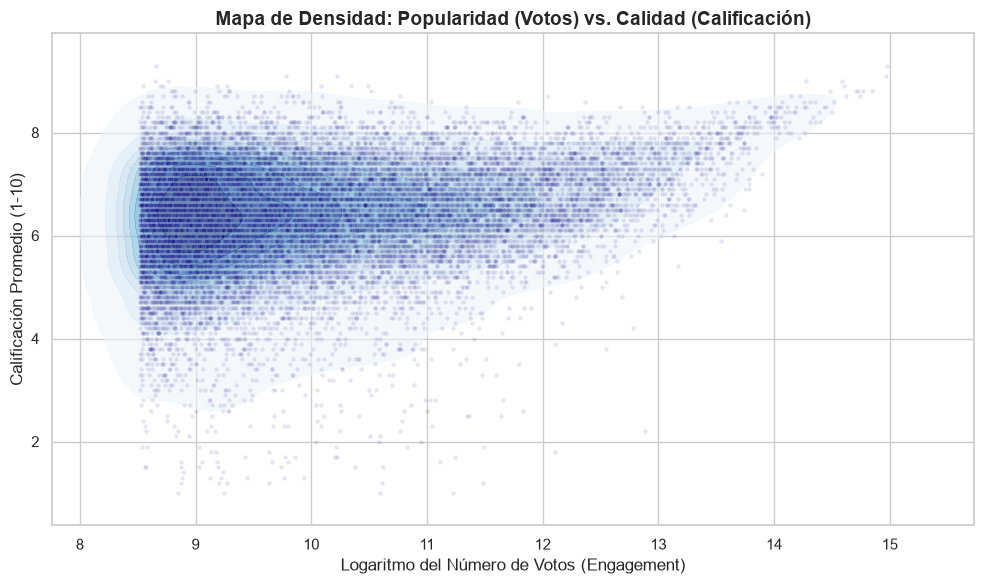

In [32]:
# 1. Configurar el lienzo y el estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Mapa de densidad de fondo
sns.kdeplot(
    data=df,
    x='log_num_votes',
    y='average_rating',
    cmap="Blues",
    fill=True,
    thresh=0.02,
    alpha=0.6
)

# 3. Sobreponer los puntos con mucha transparencia para ver las fronteras
sns.scatterplot(
    data=df,
    x='log_num_votes',
    y='average_rating',
    color='navy',
    alpha=0.1,
    s=10
)

# 4. Personalizar títulos y etiquetas
plt.title('Mapa de Densidad: Popularidad (Votos) vs. Calidad (Calificación)',
          fontsize=14, fontweight='bold')
plt.xlabel('Logaritmo del Número de Votos (Engagement)', fontsize=12)
plt.ylabel('Calificación Promedio (1-10)', fontsize=12)

plt.tight_layout()
plt.show()

El análisis de densidad bivariada demuestra que el volumen de interacción de la comunidad (votos) actúa como un potente filtro de validación de calidad. Se evidencia un fenómeno de "Embudo de la Fama": mientras que en los niveles de engagement bajos y moderados ($log\_num\_votes < 11$) las películas se dispersan por todo el espectro de calificaciones, al cruzar la barrera de la alta popularidad la varianza se reduce drásticamente y los datos convergen exclusivamente en puntuaciones sobresalientes ($> 7.5$).Esto desmitifica la existencia masiva de blockbusters altamente populares pero universalmente rechazados, demostrando que en el ecosistema de IMDb, alcanzar un estatus de distribución y participación masiva está intrínsecamente ligado a una percepción de calidad positiva por parte de la audiencia global.

# **CONCLUSIÓN GENERAL**

El presente proyecto completó exitosamente un pipeline integral de Ciencia de Datos sobre un catálogo de 16,251 películas de IMDb, logrando transformar un dataset inicialmente ruidoso en un recurso con 100% de integridad y libre de valores nulos.

A través del Análisis Exploratorio de Datos (EDA) Avanzado, se extrajeron cuatro grandes hallazgos sobre el comportamiento de la industria y el consumo cinematográfico entre 1980 y 2026:

1. **Evolución Temporal:** Las calificaciones promedio han decrecido gradualmente desde los años 90 debido a la masificación del contenido vía streaming. Asimismo, las métricas capturaron con precisión quirúrgica el desplome de la industria global en el año 2020 debido a la pandemia.

2. **El Filtro de la Duración:** Se derribó el mito de que el cine largo fatiga al espectador. Existe una correlación positiva que demuestra que las películas que superan los 140 minutos mantienen un estándar de calidad superior, erradicando casi por completo los fracasos críticos.

3. **Polarización por Géneros:** El público premia con consistencia al cine de no-ficción y cultura (Documentales, Biografías e Historia), mientras que castiga severamente a las producciones comerciales masivas de bajo presupuesto, posicionando al Terror (Horror) con el peor desempeño estadístico.

4. **Validación de la Popularidad:** El volumen de votos funciona como un certificado de calidad. Aunque las películas poco votadas abarcan cualquier nota, los fenómenos de masas con engagement extremo convergen exclusivamente en calificaciones sobresalientes ($>7.5$).

Reflexión final: La correcta curación y auditoría visual de las variables numéricas y categóricas realizada en este cuaderno garantiza que el dataset está óptimamente preparado para cualquier fase posterior de modelado predictivo o sistemas de recomendación.